In [1]:
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

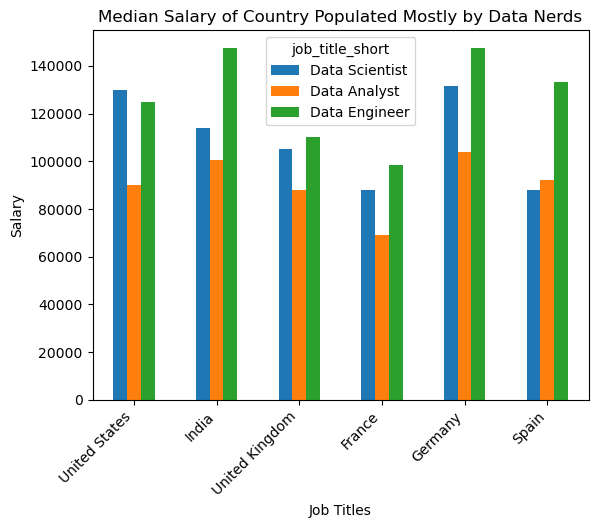

In [21]:
df_job_country_salary = df.pivot_table(values='salary_year_avg', index='job_country', columns='job_title_short', aggfunc='median', sort=False)
top_countries = df['job_country'].value_counts().head(6).index
#making pivot table to plot with top_countries as indices
df_job_country_salary = df_job_country_salary.loc[top_countries]
job_titles = ['Data Scientist', 'Data Analyst', 'Data Engineer']
df_job_country_salary = df_job_country_salary[job_titles]
df_job_country_salary.plot(kind='bar')
plt.xlabel('Job Titles')
plt.xticks(rotation=45, ha='right')
plt.title('Median Salary of Country Populated Mostly by Data Nerds')
plt.ylabel('Salary')
plt.show()

In [24]:
df.groupby(['job_title_short', 'job_country'])['salary_year_avg'].median().dropna()

job_title_short    job_country         
Business Analyst   Argentina                71100.0
                   Australia                70000.0
                   Bangladesh               16500.0
                   Belgium                  89100.0
                   Bulgaria                 71925.0
                                             ...   
Software Engineer  Ukraine                  54000.0
                   United Arab Emirates     79200.0
                   United Kingdom           89100.0
                   United States           130000.0
                   Vietnam                  53600.0
Name: salary_year_avg, Length: 598, dtype: float64

In [ ]:
df_job_country_salary = df.pivot_table(values='salary_year_avg', index='job_country', columns='job_title_short', aggfunc='median', sort=False)
df_job_country_salary.loc['Bulgaria', 'Business Analyst']
#This only proves that the same can be done using groupby but it is harder to plot since groupby does not transform data into a table.
#Both method provides the same data, there is no discrepancy at all. It is just using pivot_table is much organized and therefore much easier to use in plotting.
#The edge of using pivot_table over groupby in this case is to make much usuable table for plotting purposes.

71925.0

In [8]:
df.groupby(['job_title_short','job_country'])['salary_year_avg'].median().dropna().loc['Data Analyst']

job_country
Albania            49950.00
Algeria            44100.00
Argentina          92771.75
Armenia           100500.00
Australia         109500.00
                    ...    
United Kingdom     87750.00
United States      90000.00
Uruguay           100500.00
Vietnam            75550.00
Zimbabwe           63000.00
Name: salary_year_avg, Length: 87, dtype: float64

In [28]:
list_bool = df['job_title_short'] == 'Data Analyst'